In [8]:
import torch
import numpy as np
import random
import matplotlib
import pandas as pd

# Set seeds for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# If using GPU
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# Print versions
print("Torch:", torch.__version__)
print("Numpy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Pandas:", pd.__version__)

# Check GPU
print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

Torch: 2.10.0+cu128
Numpy: 2.0.2
Matplotlib: 3.10.0
Pandas: 2.2.2
GPU Available: True
GPU Name: Tesla T4


**PROBLEM** **2**

In [9]:
from torchvision import datasets

mnist_train = datasets.MNIST(root='./data', train=True, download=True)
mnist_test = datasets.MNIST(root='./data', train=False, download=True)

cifar_train = datasets.CIFAR10(root='./data', train=True, download=True)
cifar_test = datasets.CIFAR10(root='./data', train=False, download=True)

# Convert to numpy
mnist_data = mnist_train.data.numpy()
mnist_labels = mnist_train.targets.numpy()

cifar_data = np.array(cifar_train.data)
cifar_labels = np.array(cifar_train.targets)

# Print shapes
print("MNIST Train:", mnist_data.shape)
print("MNIST Test:", mnist_test.data.shape)

print("CIFAR Train:", cifar_data.shape)
print("CIFAR Test:", np.array(cifar_test.data).shape)

# Data type and range
print("MNIST dtype:", mnist_data.dtype, "Range:", mnist_data.min(), "-", mnist_data.max())
print("CIFAR dtype:", cifar_data.dtype, "Range:", cifar_data.min(), "-", cifar_data.max())

# Class distribution MNIST
unique, counts = np.unique(mnist_labels, return_counts=True)
print(dict(zip(unique, counts)))

MNIST Train: (60000, 28, 28)
MNIST Test: torch.Size([10000, 28, 28])
CIFAR Train: (50000, 32, 32, 3)
CIFAR Test: (10000, 32, 32, 3)
MNIST dtype: uint8 Range: 0 - 255
CIFAR dtype: uint8 Range: 0 - 255
{np.int64(0): np.int64(5923), np.int64(1): np.int64(6742), np.int64(2): np.int64(5958), np.int64(3): np.int64(6131), np.int64(4): np.int64(5842), np.int64(5): np.int64(5421), np.int64(6): np.int64(5918), np.int64(7): np.int64(6265), np.int64(8): np.int64(5851), np.int64(9): np.int64(5949)}


**PROBLEM 3**

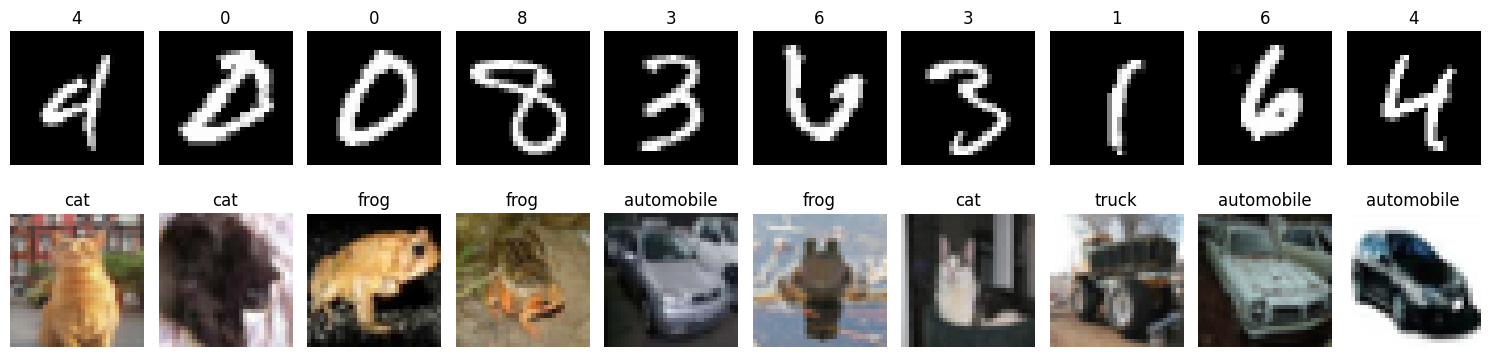

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 10, figsize=(15,4))

# MNIST
for i in range(10):
    idx = np.random.randint(0, len(mnist_data))
    axes[0,i].imshow(mnist_data[idx], cmap='gray')
    axes[0,i].set_title(mnist_labels[idx])
    axes[0,i].axis('off')

# CIFAR
classes = cifar_train.classes
for i in range(10):
    idx = np.random.randint(0, len(cifar_data))
    axes[1,i].imshow(cifar_data[idx])
    axes[1,i].set_title(classes[cifar_labels[idx]])
    axes[1,i].axis('off')

plt.tight_layout()
plt.savefig("dataset_samples.png")
plt.show()

In [11]:
def preprocess(images, labels, is_mnist=True):
    print("Before:", images.shape, images.dtype)

    # Normalize
    images = images.astype(np.float32) / 255.0

    print("After normalization:", images.min(), images.max(), images.dtype)

    # Add channel for MNIST
    if is_mnist:
        images = np.expand_dims(images, axis=-1)

    print("After reshape:", images.shape)

    # One-hot encoding
    one_hot = np.zeros((labels.shape[0], 10))
    one_hot[np.arange(labels.shape[0]), labels] = 1

    print("One-hot shape:", one_hot.shape)

    return images, one_hot

**PROBLEM 4**

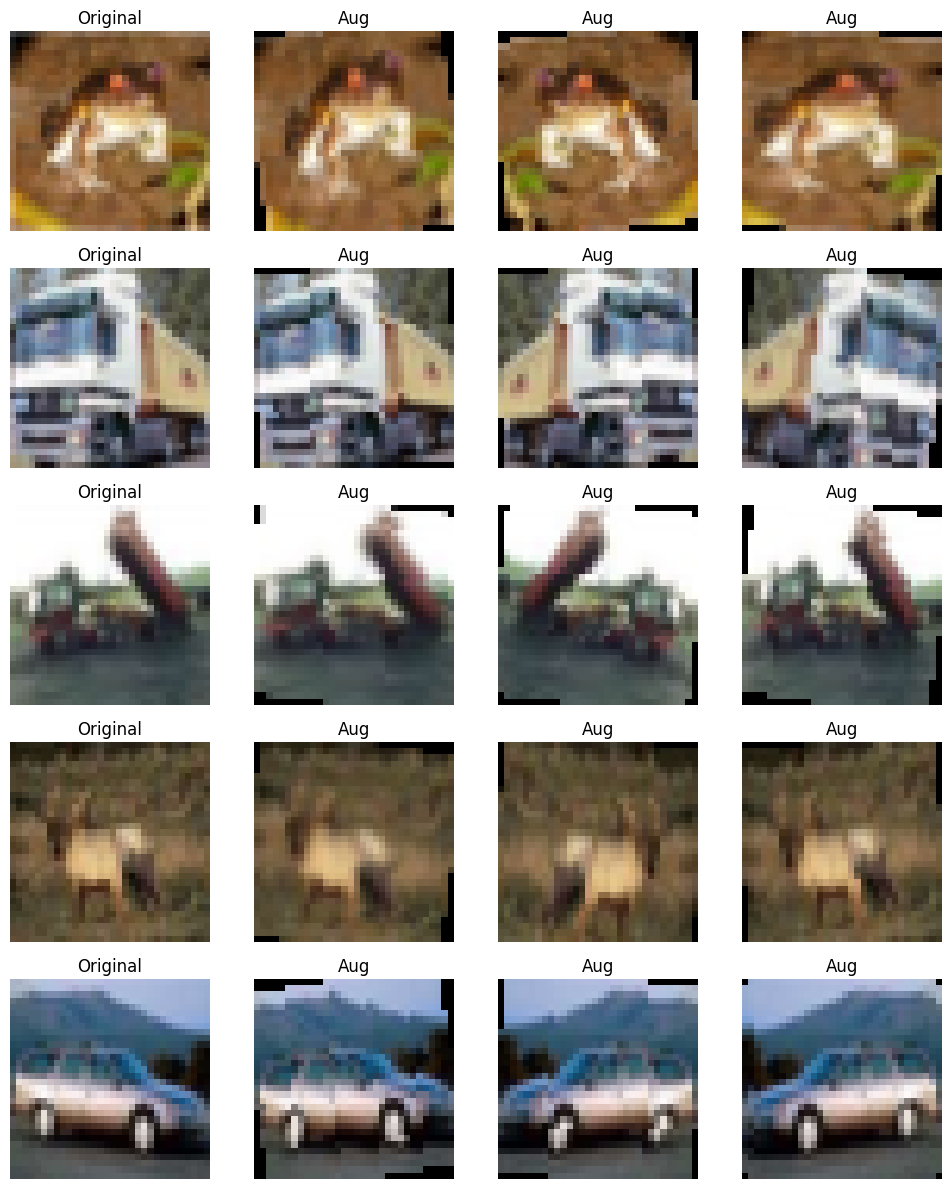

In [12]:
import torchvision.transforms as transforms
from PIL import Image

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(32, scale=(0.9, 1.1))
])

fig, axes = plt.subplots(5,4, figsize=(10,12))

for i in range(5):
    img = cifar_data[i]
    pil_img = Image.fromarray(img)

    axes[i,0].imshow(img)
    axes[i,0].set_title("Original")
    axes[i,0].axis('off')

    for j in range(1,4):
        aug_img = transform(pil_img)
        axes[i,j].imshow(aug_img)
        axes[i,j].set_title("Aug")
        axes[i,j].axis('off')

plt.tight_layout()
plt.savefig("augmentation_demo.png")
plt.show()

**TASK 2
PROBLEM 1**

In [13]:
import numpy as np

def conv2d(image, kernel, stride=1, padding=0):
    # Add padding
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')

    H, W = image.shape
    kH, kW = kernel.shape

    # Output dimensions
    out_H = (H - kH) // stride + 1
    out_W = (W - kW) // stride + 1

    output = np.zeros((out_H, out_W))

    for i in range(0, out_H):
        for j in range(0, out_W):
            region = image[i*stride:i*stride+kH, j*stride:j*stride+kW]
            output[i, j] = np.sum(region * kernel)

    return output

In [14]:
image = np.array([
    [3,1,0,2,4],
    [1,5,3,2,1],
    [0,2,6,4,3],
    [2,3,1,5,2],
    [1,0,2,3,4]
])

kernel = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
])

output = conv2d(image, kernel, stride=1, padding=0)
print(output)
print("Output shape:", output.shape)

[[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]
Output shape: (3, 3)


**PROBLEM 2**

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()

        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)   # 28 → 24
        self.pool = nn.AvgPool2d(2, 2)                # 24 → 12
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)  # 12 → 8

        self.fc1 = nn.Linear(16*4*4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = torch.tanh(self.conv1(x))
        x = self.pool(x)

        x = torch.tanh(self.conv2(x))
        x = self.pool(x)

        x = x.view(-1, 16*4*4)

        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = F.softmax(self.fc3(x), dim=1)

        return x

**PROBELM 3**

In [16]:
model = LeNet5()
total = sum(p.numel() for p in model.parameters())
print("Total parameters:", total)

Total parameters: 44426


**PROBLEM 4**

In [26]:
class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()

        # Changed input channels from 3 to 1 for MNIST dataset
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2,2)

        self.gap = nn.AdaptiveAvgPool2d((1,1))

        self.fc1 = nn.Linear(128, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = self.gap(x)
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# Transform
transform = transforms.Compose([
    transforms.ToTensor()
])

# Dataset
dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Split (90% train, 10% val)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_data, val_data = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64)

# Model
model = LeNet5()

# Loss + Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

train_loss, val_loss = [], []
train_acc, val_acc = [], []

# Training loop
for epoch in range(15):
    model.train()
    correct, total, running_loss = 0, 0, 0

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss.append(running_loss/len(train_loader))
    train_acc.append(correct/total)

    # Validation
    model.eval()
    correct, total, running_loss = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss.append(running_loss/len(val_loader))
    val_acc.append(correct/total)

    print(f"Epoch {epoch+1}: Train Acc={train_acc[-1]:.4f}, Val Acc={val_acc[-1]:.4f}")

Epoch 1: Train Acc=0.0986, Val Acc=0.1027
Epoch 2: Train Acc=0.1193, Val Acc=0.1360
Epoch 3: Train Acc=0.1743, Val Acc=0.2112
Epoch 4: Train Acc=0.2482, Val Acc=0.2680
Epoch 5: Train Acc=0.2690, Val Acc=0.2603
Epoch 6: Train Acc=0.3185, Val Acc=0.3285
Epoch 7: Train Acc=0.3523, Val Acc=0.3787
Epoch 8: Train Acc=0.4626, Val Acc=0.5508
Epoch 9: Train Acc=0.6100, Val Acc=0.6452
Epoch 10: Train Acc=0.6689, Val Acc=0.7188
Epoch 11: Train Acc=0.7566, Val Acc=0.7832
Epoch 12: Train Acc=0.7945, Val Acc=0.8077
Epoch 13: Train Acc=0.8305, Val Acc=0.8555
Epoch 14: Train Acc=0.8654, Val Acc=0.8738
Epoch 15: Train Acc=0.8789, Val Acc=0.8845


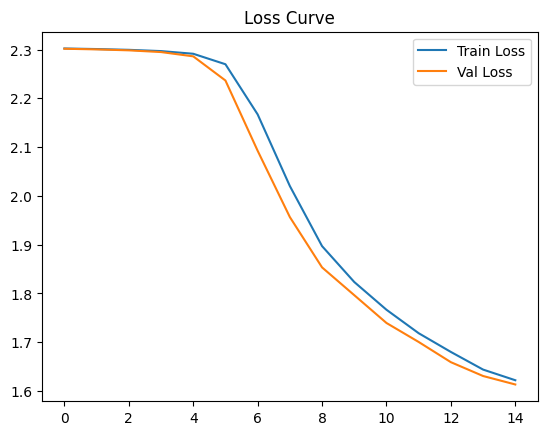

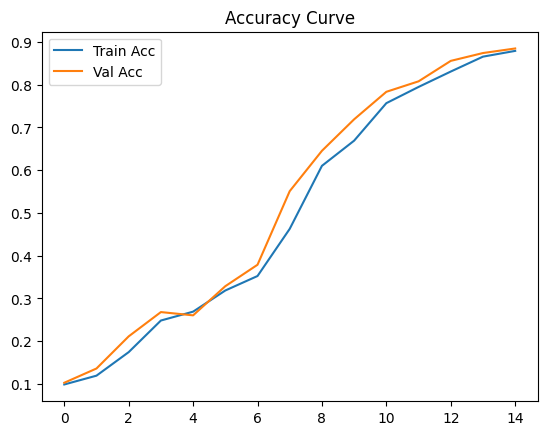

In [20]:
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.savefig("lenet_sgd_curves.png")
plt.show()

plt.plot(train_acc, label="Train Acc")
plt.plot(val_acc, label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [21]:
optimizers = {
    "SGD": optim.SGD(model.parameters(), lr=0.01),
    "Momentum": optim.SGD(model.parameters(), lr=0.01, momentum=0.9),
    "Adam": optim.Adam(model.parameters(), lr=0.001)
}

In [27]:
learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]

results = {}

# Assuming `criterion` (nn.CrossEntropyLoss) is defined globally or earlier
criterion = nn.CrossEntropyLoss()

for lr in learning_rates:
    for bs in batch_sizes:
        model = CustomCNN()
        optimizer = optim.SGD(model.parameters(), lr=lr)

        train_loader = DataLoader(train_data, batch_size=bs, shuffle=True)
        val_loader = DataLoader(val_data, batch_size=bs)

        # Training loop for 10 epochs
        current_val_acc = 0.0
        for epoch in range(10): # Train for 10 epochs as indicated in comments
            model.train()
            correct, total = 0, 0
            for images, labels in train_loader:
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

            # Validation step after each epoch
            model.eval()
            correct, total = 0, 0
            with torch.no_grad():
                for images, labels in val_loader:
                    outputs = model(images)
                    _, preds = torch.max(outputs, 1)
                    correct += (preds == labels).sum().item()
                    total += labels.size(0)
            current_val_acc = correct / total

        # Save final val accuracy
        final_val_acc = current_val_acc
        results[(lr, bs)] = final_val_acc

print("Hyperparameter search results:")
for (lr, bs), acc in results.items():
    print(f"  LR: {lr}, Batch Size: {bs}, Final Val Acc: {acc:.4f}")

Hyperparameter search results:
  LR: 0.1, Batch Size: 32, Final Val Acc: 0.9918
  LR: 0.1, Batch Size: 128, Final Val Acc: 0.9887
  LR: 0.01, Batch Size: 32, Final Val Acc: 0.9858
  LR: 0.01, Batch Size: 128, Final Val Acc: 0.9728
  LR: 0.001, Batch Size: 32, Final Val Acc: 0.9655
  LR: 0.001, Batch Size: 128, Final Val Acc: 0.7845


In [28]:
nn.Dropout(0.3)

Dropout(p=0.3, inplace=False)

In [41]:
nn.BatchNorm2d(32)

BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

In [31]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, factor=0.5, patience=3
)

In [32]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=30
)

**TASK 4 PROBLEM 1**

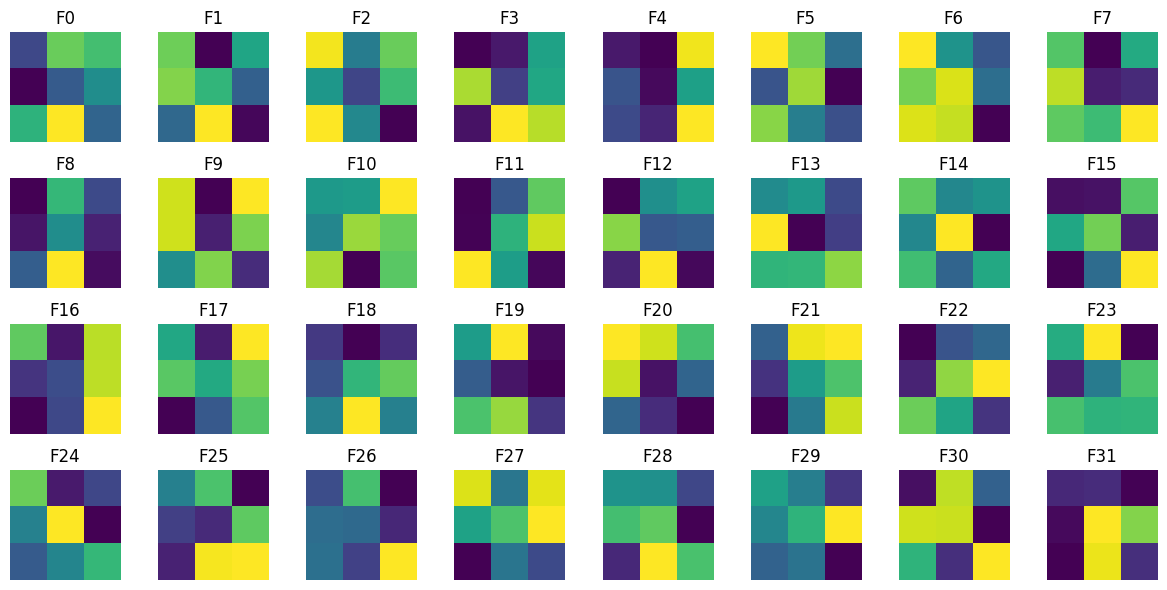

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Get first conv layer weights
weights = model.conv1.weight.data.cpu().numpy()  # shape: (out_channels, in_channels, k, k)

num_filters = weights.shape[0]

fig, axes = plt.subplots(4, 8, figsize=(12,6))  # adjust grid as needed

for i, ax in enumerate(axes.flat):
    if i < num_filters:
        filt = weights[i]

        # For RGB → average channels
        filt = np.mean(filt, axis=0)

        # Normalize
        filt = (filt - filt.min()) / (filt.max() - filt.min() + 1e-5)

        ax.imshow(filt)
        ax.set_title(f"F{i}")
        ax.axis('off')

plt.tight_layout()
plt.savefig("conv1_filters.png")
plt.show()

In [34]:
from torch import nn

def get_feature_maps(model, x):
    activations = []

    def hook_fn(module, input, output):
        activations.append(output)

    hooks = []
    for layer in [model.conv1, model.conv2, model.conv3]:
        hooks.append(layer.register_forward_hook(hook_fn))

    model(x)

    for h in hooks:
        h.remove()

    return activations

In [39]:
def plot_feature_maps(feature_maps, filename):
    fmap = feature_maps[0][0].detach().cpu().numpy()  # first image

    fig, axes = plt.subplots(1, 8, figsize=(15,3))
    for i in range(8):
        axes[i].imshow(fmap[i], cmap='gray')
        axes[i].axis('off')

    plt.savefig(filename)
    plt.show()

In [37]:
import torch.nn.functional as F

def grad_cam(model, image, target_class):
    model.eval()

    gradients = []
    activations = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    # Hook last conv layer
    last_conv = model.conv3
    last_conv.register_forward_hook(forward_hook)
    last_conv.register_backward_hook(backward_hook)

    output = model(image)
    loss = output[0, target_class]

    model.zero_grad()
    loss.backward()

    grads = gradients[0]
    acts = activations[0]

    # Global average pooling of gradients
    weights = torch.mean(grads, dim=(2,3))

    cam = torch.zeros(acts.shape[2:], dtype=torch.float32)

    for i in range(weights.shape[1]):
        cam += weights[0, i] * acts[0, i]

    cam = F.relu(cam)

    # Normalize
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    return cam.detach().cpu().numpy()

In [38]:
import cv2

def overlay_cam(image, cam):
    cam = cv2.resize(cam, (32,32))
    heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)

    img = np.transpose(image.squeeze().cpu().numpy(), (1,2,0))
    img = (img * 255).astype(np.uint8)

    overlay = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)
    return overlay

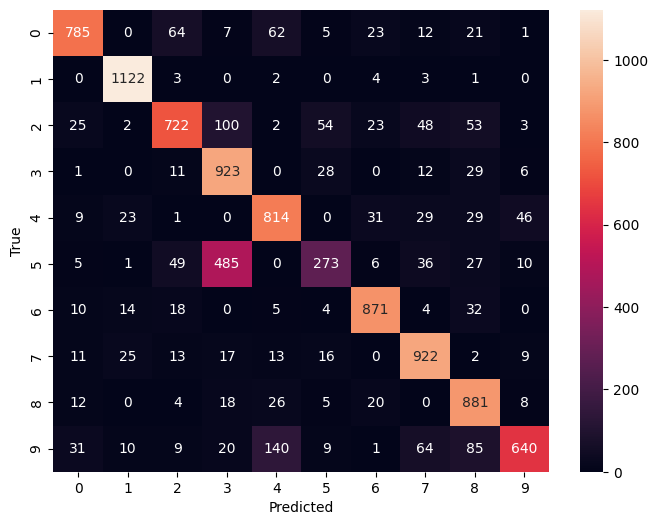

              precision    recall  f1-score   support

           0       0.88      0.80      0.84       980
           1       0.94      0.99      0.96      1135
           2       0.81      0.70      0.75      1032
           3       0.59      0.91      0.72      1010
           4       0.77      0.83      0.80       982
           5       0.69      0.31      0.42       892
           6       0.89      0.91      0.90       958
           7       0.82      0.90      0.85      1028
           8       0.76      0.90      0.83       974
           9       0.89      0.63      0.74      1009

    accuracy                           0.80     10000
   macro avg       0.80      0.79      0.78     10000
weighted avg       0.80      0.80      0.79     10000



In [42]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Define transform if not already defined (assuming it's consistent with training)
transform = transforms.Compose([
    transforms.ToTensor()
])

# Create test dataset and loader
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64)

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig("confusion_matrix.png")
plt.show()

print(classification_report(all_labels, all_preds))

**TASK 5 PROBLEM 1**

In [43]:
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader

# Transform (resize + normalize)
transform = transforms.Compose([
    transforms.Resize((96,96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

# Load pretrained model
base_model = models.resnet50(weights="IMAGENET1K_V1")

# Freeze all layers
for param in base_model.parameters():
    param.requires_grad = False

# Replace head
num_features = base_model.fc.in_features

base_model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 10)
)

model = base_model

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 202MB/s]


In [44]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)

print("Trainable:", trainable)
print("Frozen:", frozen)

Trainable: 527114
Frozen: 23508032


In [45]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

train_acc = []
val_acc = []

for epoch in range(10):
    model.train()
    correct, total = 0, 0

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = correct/total
    train_acc.append(acc)

    print(f"Epoch {epoch+1}, Train Acc: {acc:.4f}")

Epoch 1, Train Acc: 0.7066


KeyboardInterrupt: 

In [46]:
for param in model.layer4.parameters():
    param.requires_grad = True

In [47]:
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)

In [49]:
best_acc = 0
patience = 5
counter = 0

# Ensure criterion, optimizer, train_loader, and test_loader are defined
# (These are defined in previous cells: criterion/optimizer in wsDb5xJv3v3J and ShJIKkDTC23J, loaders in _THSGp1A3ePO)

# Reset val_acc and train_acc lists for fresh training
train_acc = []
val_acc = []

for epoch in range(10):
    model.train()
    correct, total = 0, 0
    running_loss = 0.0

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_train_acc = correct / total
    train_acc.append(epoch_train_acc)

    # Validation step
    model.eval()
    correct, total = 0, 0
    val_running_loss = 0.0

    with torch.no_grad():
        for images, labels in test_loader: # Using test_loader for validation as per previous code
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_val_acc = correct / total
    val_acc.append(epoch_val_acc)

    print(f"Epoch {epoch+1}: Train Acc={epoch_train_acc:.4f}, Val Acc={epoch_val_acc:.4f}")

    if val_acc[-1] > best_acc:
        best_acc = val_acc[-1]
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break

Epoch 1: Train Acc=0.8076, Val Acc=0.8455


KeyboardInterrupt: 